In [11]:
# !pip install imbalanced-learn -q

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Optional: for handling class imbalance
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("Note: imbalanced-learn not installed. SMOTE will be skipped.")

In [13]:
# Set global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

In [15]:
#load data
df1 = pd.read_csv('sectaphl1_harvestw5.csv')
df2 = pd.read_csv('sectaphl2_harvestw5.csv')

In [16]:
print(f"✅ sectaphl1 loaded: {df1.shape[0]:,} rows × {df1.shape[1]} columns")
print(f"✅ sectaphl2 loaded: {df2.shape[0]:,} rows × {df2.shape[1]} columns")
print("\n--- sectaphl1 columns ---")
print(list(df1.columns))
print("\n--- sectaphl2 columns ---")
print(list(df2.columns))

✅ sectaphl1 loaded: 40,354 rows × 19 columns
✅ sectaphl2 loaded: 7,002 rows × 70 columns

--- sectaphl1 columns ---
['zone', 'state', 'lga', 'sector', 'ea', 'hhid', 'indiv', 'cropcode', 'FILTER1', 'phl_q1', 'phl_q2', 'phl_q3', 'phl_q4__1', 'phl_q4__2', 'phl_q4__3', 'phl_q4__4', 'phl_q4__5', 'phl_q4__6', 'phl_q5']

--- sectaphl2 columns ---
['zone', 'state', 'lga', 'sector', 'ea', 'hhid', 'cropcode', 'phl_q02_1', 'phl_q03_1', 'phl_q04_1', 'phl_q05_1', 'phl_q06_1', 'phl_q07__1_1', 'phl_q07__2_1', 'phl_q07__3_1', 'phl_q07__4_1', 'phl_q07__5_1', 'phl_q07__6_1', 'phl_q02_2', 'phl_q03_2', 'phl_q04_2', 'phl_q05_2', 'phl_q06_2', 'phl_q07__1_2', 'phl_q07__2_2', 'phl_q07__3_2', 'phl_q07__4_2', 'phl_q07__5_2', 'phl_q07__6_2', 'phl_q02_3', 'phl_q03_3', 'phl_q04_3', 'phl_q05_3', 'phl_q06_3', 'phl_q07__1_3', 'phl_q07__2_3', 'phl_q07__3_3', 'phl_q07__4_3', 'phl_q07__5_3', 'phl_q07__6_3', 'phl_q08__1', 'phl_q09_1', 'phl_q10_1', 'phl_q11_1', 'phl_q12__1_1', 'phl_q12__2_1', 'phl_q12__3_1', 'phl_q12__4_1

In [17]:
print("\n" + "="*60)
print("SECTION 3: DATA CLEANING")
print("="*60)


SECTION 3: DATA CLEANING


In [18]:
# Standardise column names to lowercase
df1.columns = df1.columns.str.lower().str.strip()
df2.columns = df2.columns.str.lower().str.strip()

In [19]:
# Extract clean crop name (remove numeric code prefix)
df1['crop'] = df1['cropcode'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()


In [20]:
# Create binary target variable: 1 = Loss occurred, 0 = No loss
df1['loss_occurred'] = df1['phl_q1'].astype(str).str.contains('1\. YES|1\.YES|YES', case=False, na=False).astype(int)

In [21]:
# Clean sector (urban/rural)
df1['sector_clean'] = df1['sector'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()

# Clean zone
df1['zone_clean'] = df1['zone'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()

# Clean state
df1['state_clean'] = df1['state'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()

In [22]:
# df_q2 = storage duration (weeks), df_q3 = quantity lost
df1['storage_duration'] = pd.to_numeric(df1['phl_q2'], errors='coerce')
df1['quantity_lost'] = pd.to_numeric(df1['phl_q3'], errors='coerce')

# df_q4__1 to df_q4__6 = cause flags (pest, disease, moisture, handling, transport, other)
cause_cols = [c for c in df1.columns if c.startswith('phl_q4__')]
for col in cause_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce').fillna(0).astype(int)

In [23]:
# df_q5 = storage method
df1['storage_method'] = df1['phl_q5'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()

print(f"Target variable distribution:")
print(df1['loss_occurred'].value_counts())
print(f"\nLoss rate: {df1['loss_occurred'].mean()*100:.1f}%")


Target variable distribution:
loss_occurred
0    25653
1    14701
Name: count, dtype: int64

Loss rate: 36.4%


In [24]:
# Keep only rows where at least one loss episode occurred
# Episode 1 storage type
df2['storage_type_1'] = df2['phl_q08__1'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()
df2['storage_type_2'] = df2['phl_q08__2'].astype(str).str.extract(r'\d+\.\s*(.+)')[0].str.strip()

# Loss stage (where in supply chain did loss happen)
df2['loss_stage_1'] = pd.to_numeric(df2['phl_q03_1'], errors='coerce')
df2['loss_stage_2'] = pd.to_numeric(df2['phl_q03_2'], errors='coerce')

# Quantity lost in each episode
df2['qty_lost_1'] = pd.to_numeric(df2['phl_q04_1'], errors='coerce')
df2['qty_lost_2'] = pd.to_numeric(df2['phl_q04_2'], errors='coerce')

# Value lost
df2['value_lost_1'] = pd.to_numeric(df2['phl_q06_1'], errors='coerce')


In [25]:
# Cause flags from episode 1
cause2_cols = [c for c in df2.columns if 'phl_q07__' in c and c.endswith('_1')]
for col in cause2_cols:
    df2[col] = pd.to_numeric(df2[col], errors='coerce').fillna(0).astype(int)

print("\n✅ Both files cleaned.")


✅ Both files cleaned.


In [26]:
#3.3 Merge the two files

merge_keys = ['hhid', 'cropcode']

# Check merge keys exist in both
for key in merge_keys:
    assert key in df1.columns, f"Missing {key} in df1"
    assert key in df2.columns, f"Missing {key} in df2"

df = df1.merge(df2, on=merge_keys, how='left', suffixes=('_p1', '_p2'))

print(f"\nMerged dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Rows after merge: {len(df):,}")


Merged dataset shape: 40,354 rows × 102 columns
Rows after merge: 40,354


In [27]:
#missing values
# Fill cause flags with 0 (no loss = no cause)
flag_cols = [c for c in df.columns if 'phl_q4__' in c or 'phl_q07__' in c]
df[flag_cols] = df[flag_cols].fillna(0)

# Fill numeric with median
num_cols = ['storage_duration', 'quantity_lost', 'qty_lost_1', 'qty_lost_2', 'value_lost_1']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [28]:
# Fill categorical with 'Unknown'
cat_cols = ['sector_clean', 'zone_clean', 'storage_method', 'storage_type_1', 'crop']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [29]:
print(f"\nMissing values after cleaning:")
print(df[['loss_occurred', 'storage_duration', 'quantity_lost', 'sector_clean', 'zone_clean']].isnull().sum())
print("\n✅ Data cleaning complete.")



Missing values after cleaning:
loss_occurred       0
storage_duration    0
quantity_lost       0
sector_clean        0
zone_clean          0
dtype: int64

✅ Data cleaning complete.


In [30]:
print("\n" + "="*60)
print("SECTION 4: EXPLORATORY DATA ANALYSIS")
print("="*60)


SECTION 4: EXPLORATORY DATA ANALYSIS


In [31]:
# Summary of numeric variables
stats_summary = df[num_cols + ['loss_occurred']].describe().T
print("\n📊 Summary Statistics for Key Variables:")
print(stats_summary[['mean', 'std', 'min', '50%', 'max']].round(2))

# Loss occurrence by Zone
zone_stats = pd.crosstab(df['zone_clean'], df['loss_occurred'], normalize='index') * 100
print("\n🌍 Loss Occurrence Rate by Geographic Zone (%):")
print(zone_stats.round(2))


📊 Summary Statistics for Key Variables:
                     mean     std    min     50%      max
storage_duration     3.19    1.78    1.0     3.0     48.0
quantity_lost        3.98    1.07    0.5     4.0     16.0
qty_lost_1           3.02    1.23    1.0     3.0     30.0
qty_lost_2           2.11    0.65    1.0     2.0     14.0
value_lost_1      2106.10  930.94  200.0  2000.0  40000.0
loss_occurred        0.36    0.48    0.0     0.0      1.0

🌍 Loss Occurrence Rate by Geographic Zone (%):
loss_occurred      0      1
zone_clean                 
North Central  57.08  42.92
North East     58.20  41.80
North West     68.75  31.25
South East     71.65  28.35
South South    60.71  39.29
South West     72.17  27.83


In [32]:
# Categorical Frequency
print("\n🌍 Distribution by Geographic Zone:")
print(df['zone_clean'].value_counts())

print("\n🌾 Top 5 Crops in Dataset:")
print(df['crop'].value_counts().head(5))


🌍 Distribution by Geographic Zone:
zone_clean
North East       11554
North West       11131
North Central     7108
South East        4814
South South       3296
South West        2451
Name: count, dtype: int64

🌾 Top 5 Crops in Dataset:
crop
MAIZE                    8152
GUINEA CORN (SORGHUM)    5395
MILLET/MAIWA             3430
RICE                     3368
BEANS/COWPEA             3307
Name: count, dtype: int64


In [34]:
# Set global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


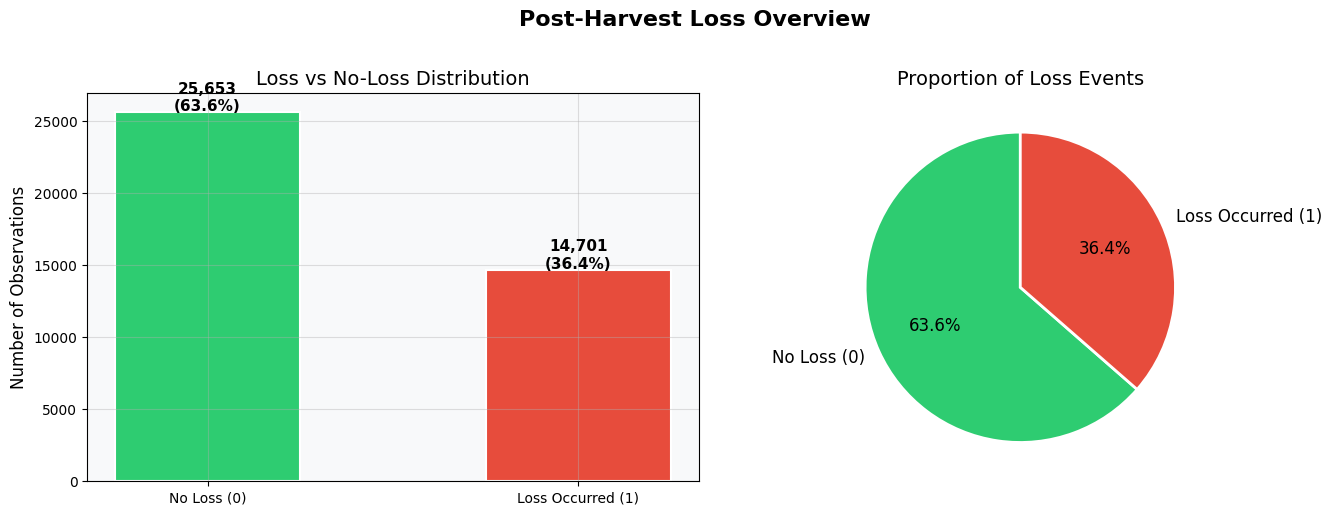

In [35]:
# ── 4.1 Target Variable Distribution ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Post-Harvest Loss Overview', fontsize=16, fontweight='bold', y=1.02)

counts = df['loss_occurred'].value_counts()
labels = ['No Loss (0)', 'Loss Occurred (1)']
colors = [PALETTE[0], PALETTE[1]]
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Loss vs No-Loss Distribution')
axes[0].set_ylabel('Number of Observations')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                  f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Loss Events')

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

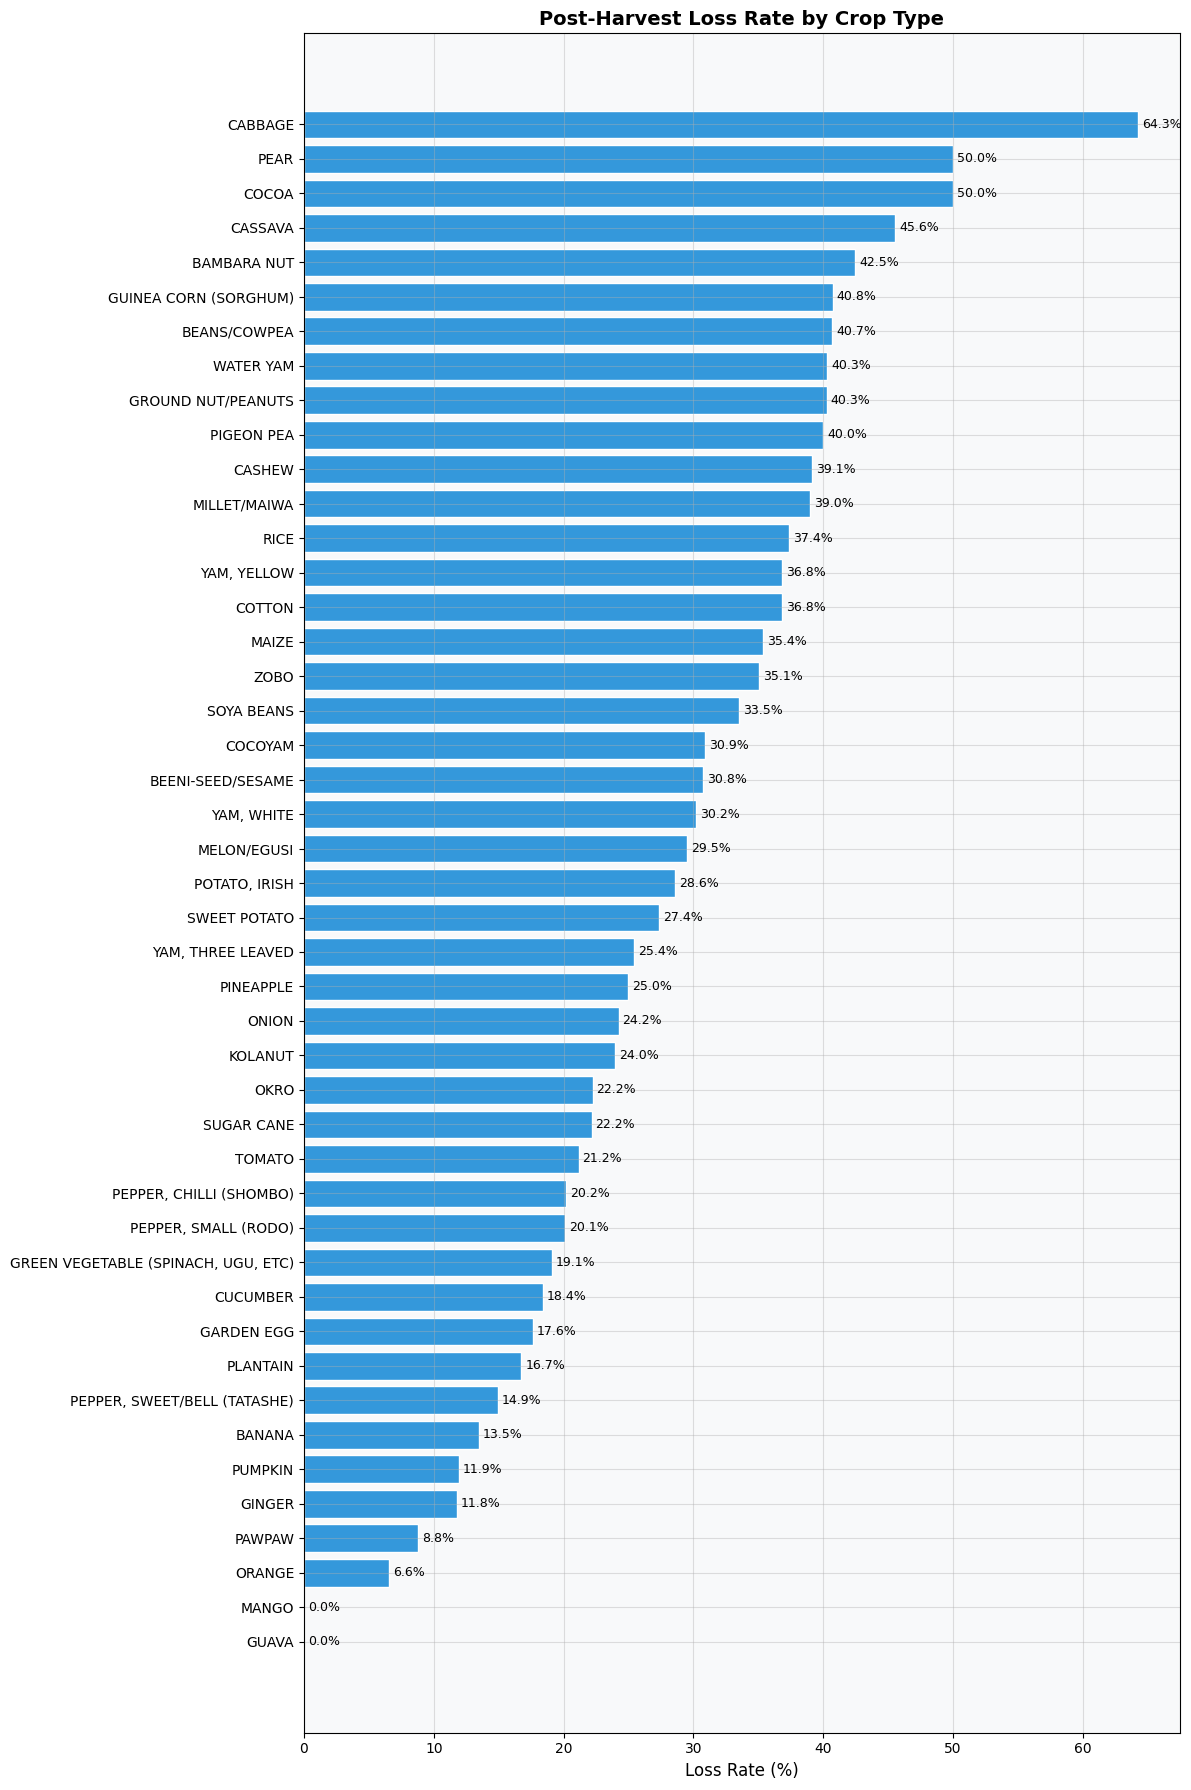

In [36]:
# ── 4.2 Loss by Crop Type ────────────────────────────────────

if 'crop' in df.columns:
    crop_loss = df.groupby('crop')['loss_occurred'].agg(['mean', 'count']).reset_index()
    crop_loss.columns = ['crop', 'loss_rate', 'count']
    crop_loss = crop_loss[crop_loss['count'] >= 10].sort_values('loss_rate', ascending=True)
    crop_loss['loss_pct'] = crop_loss['loss_rate'] * 100

    fig, ax = plt.subplots(figsize=(12, max(6, len(crop_loss) * 0.4)))
    bars = ax.barh(crop_loss['crop'], crop_loss['loss_pct'],
                    color=PALETTE[2], edgecolor='white', linewidth=1)
    ax.set_xlabel('Loss Rate (%)')
    ax.set_title('Post-Harvest Loss Rate by Crop Type', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, crop_loss['loss_pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig2_loss_by_crop.png', dpi=150, bbox_inches='tight')
    plt.show()

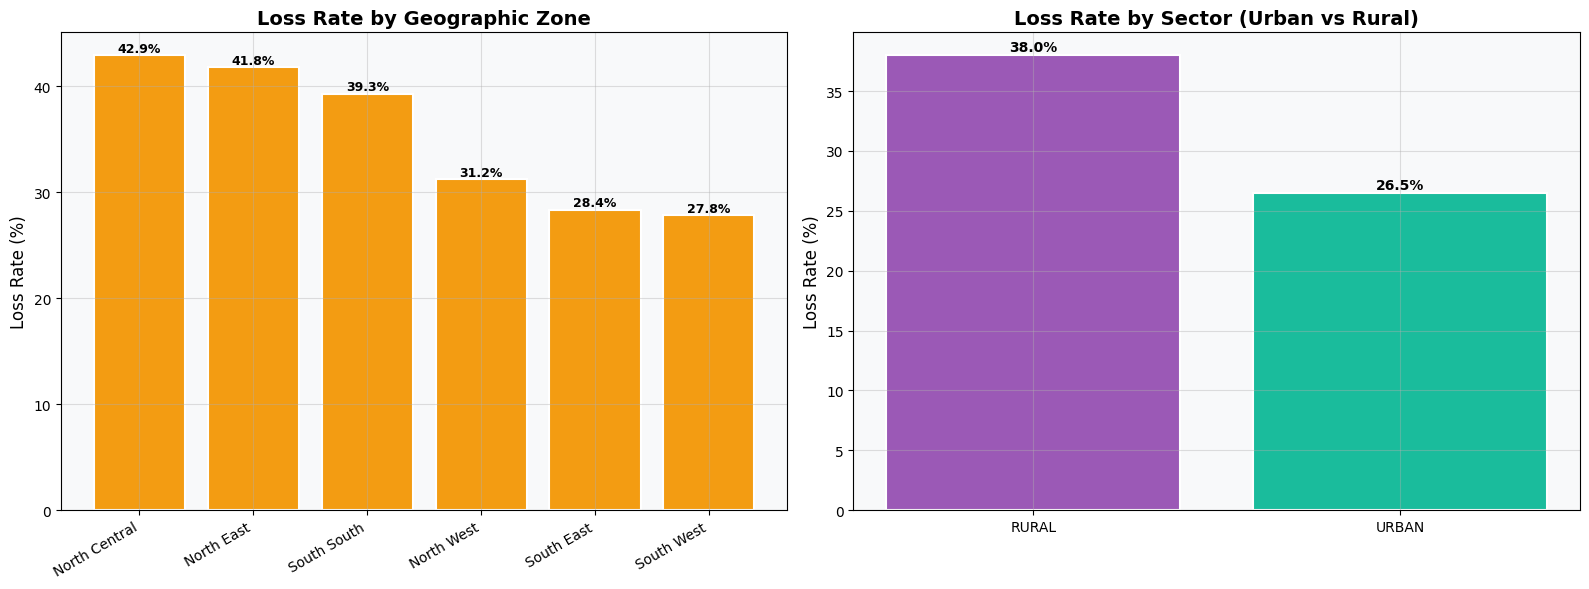

In [37]:
# ── 4.3 Loss by Zone and Sector ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By zone
zone_loss = df.groupby('zone_clean')['loss_occurred'].mean().sort_values(ascending=False) * 100
axes[0].bar(zone_loss.index, zone_loss.values, color=PALETTE[3], edgecolor='white', linewidth=1.5)
axes[0].set_title('Loss Rate by Geographic Zone', fontweight='bold')
axes[0].set_ylabel('Loss Rate (%)')
axes[0].set_xticklabels(zone_loss.index, rotation=30, ha='right')
for i, (idx, val) in enumerate(zone_loss.items()):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# By sector
sector_loss = df.groupby('sector_clean')['loss_occurred'].mean().sort_values(ascending=False) * 100
axes[1].bar(sector_loss.index, sector_loss.values,
            color=[PALETTE[4], PALETTE[5]][:len(sector_loss)], edgecolor='white', linewidth=1.5)
axes[1].set_title('Loss Rate by Sector (Urban vs Rural)', fontweight='bold')
axes[1].set_ylabel('Loss Rate (%)')
for i, (idx, val) in enumerate(sector_loss.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_loss_by_zone_sector.png', dpi=150, bbox_inches='tight')
plt.show()

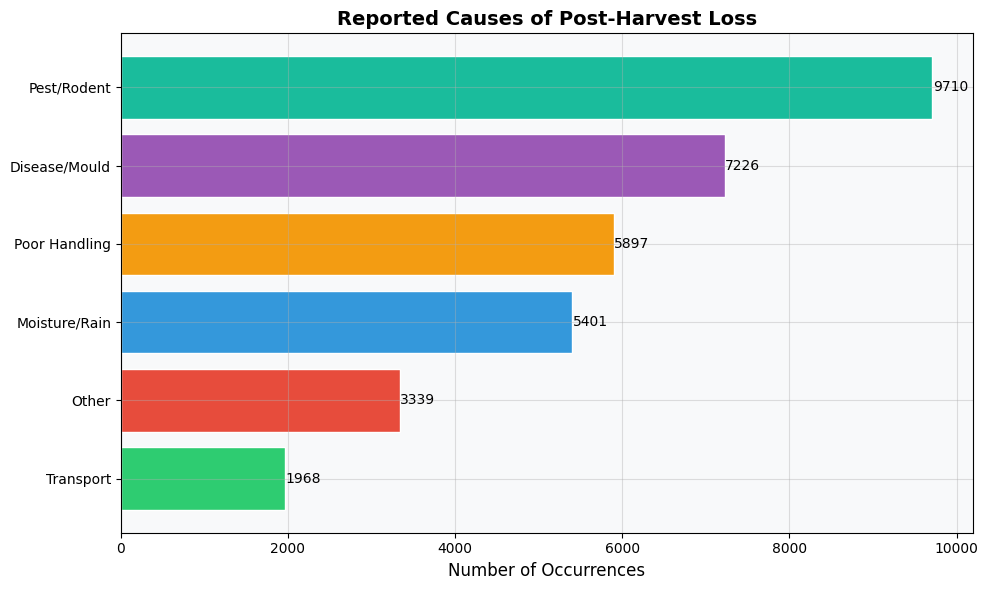

In [38]:
# ── 4.4 Causes of Loss ───────────────────────────────────────

cause_labels = {
    'phl_q4__1': 'Pest/Rodent',
    'phl_q4__2': 'Disease/Mould',
    'phl_q4__3': 'Moisture/Rain',
    'phl_q4__4': 'Poor Handling',
    'phl_q4__5': 'Transport',
    'phl_q4__6': 'Other'
}
existing_causes = {k: v for k, v in cause_labels.items() if k in df.columns}
if existing_causes:
    cause_df = df[list(existing_causes.keys())].sum().reset_index()
    cause_df.columns = ['code', 'count']
    cause_df['label'] = cause_df['code'].map(existing_causes)
    cause_df = cause_df.sort_values('count', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(cause_df['label'], cause_df['count'],
                   color=PALETTE[:len(cause_df)], edgecolor='white', linewidth=1)
    ax.set_title('Reported Causes of Post-Harvest Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Occurrences')
    for bar, val in zip(bars, cause_df['count']):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                str(int(val)), va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig4_causes_of_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

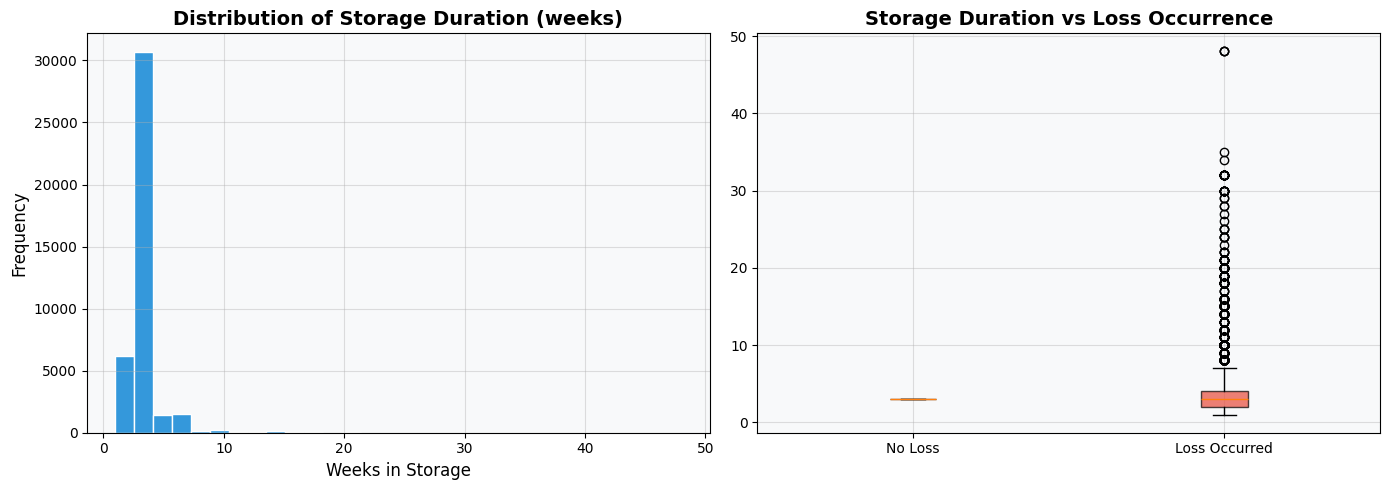

In [39]:
# ── 4.5 Storage Duration Distribution ───────────────────────

if 'storage_duration' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df['storage_duration'].dropna().plot.hist(bins=30, ax=axes[0], color=PALETTE[2], edgecolor='white')
    axes[0].set_title('Distribution of Storage Duration (weeks)', fontweight='bold')
    axes[0].set_xlabel('Weeks in Storage')

    data_by_loss = [df[df['loss_occurred'] == 0]['storage_duration'].dropna(),
                    df[df['loss_occurred'] == 1]['storage_duration'].dropna()]
    bp = axes[1].boxplot(data_by_loss, patch_artist=True, labels=['No Loss', 'Loss Occurred'])
    for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_title('Storage Duration vs Loss Occurrence', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig5_storage_duration.png', dpi=150, bbox_inches='tight')
    plt.show()

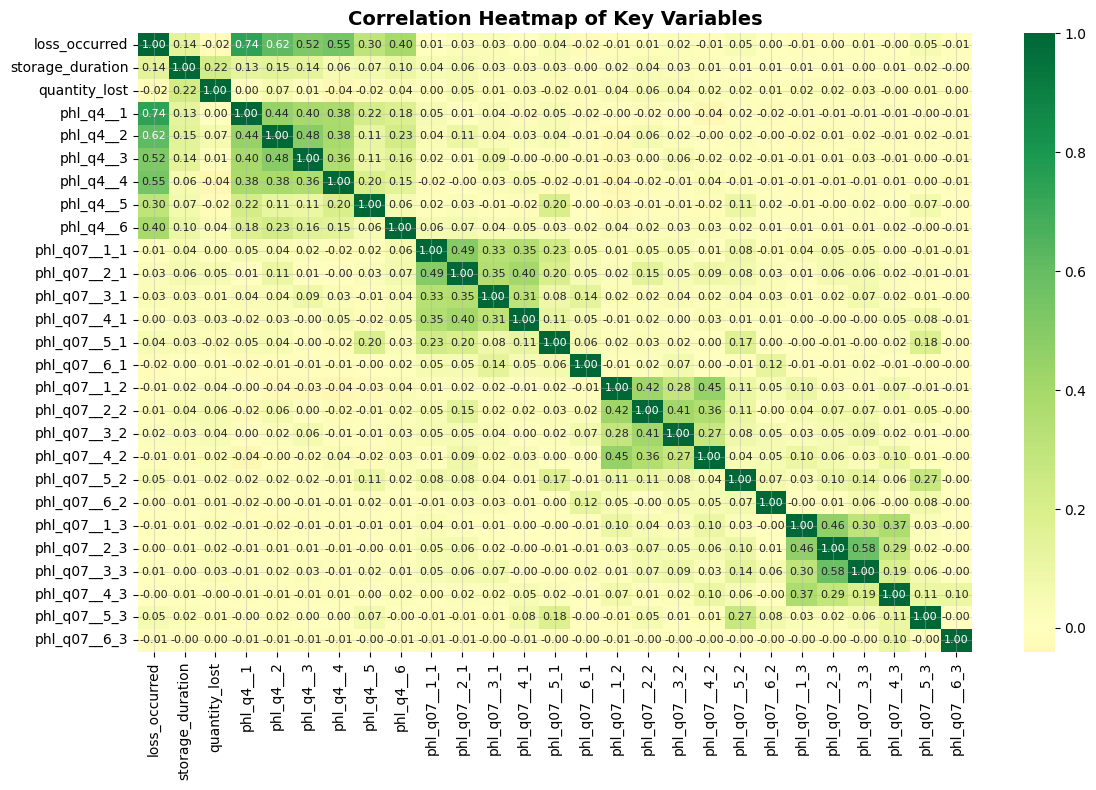

In [40]:
# ── 4.6 Correlation Heatmap ──────────────────────────────────

numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.loc[:, numeric_df.std() > 0.01]
relevant_cols = ['loss_occurred', 'storage_duration', 'quantity_lost'] + \
                [c for c in numeric_df.columns if 'phl_q4' in c or 'phl_q07' in c]
relevant_cols = [c for c in relevant_cols if c in numeric_df.columns]

if len(relevant_cols) > 1:
    corr_matrix = numeric_df[relevant_cols].corr()
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, annot_kws={'size': 8})
    ax.set_title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [41]:
print("\n" + "="*60)
print("SECTION 5: FEATURE ENGINEERING")
print("="*60)


SECTION 5: FEATURE ENGINEERING


In [57]:
feature_cols = []

# 1. Geographic & Demographic Predictors
cat_features = ['zone_clean', 'sector_clean', 'crop']
for col in cat_features:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
        feature_cols.append(f'{col}_enc')

# 2. Storage Characteristics (A true predictor)
if 'storage_method' in df.columns:
    le_storage = LabelEncoder()
    df['storage_method_enc'] = le_storage.fit_transform(df['storage_method'].astype(str))
    feature_cols.append('storage_method_enc')

# 3. Temporal Predictors
if 'storage_duration' in df.columns:
    feature_cols.append('storage_duration')

# Build final X and y
X = df[feature_cols].copy().fillna(0)
y = df['loss_occurred'].copy()

# Feature display mapping for the student's report
feature_display_names = {
    'zone_clean_enc': 'Geographic Zone',
    'sector_clean_enc': 'Sector (Urban/Rural)',
    'crop_enc': 'Crop Variety',
    'storage_method_enc': 'Storage Method Used',
    'storage_duration': 'Duration of Storage (Weeks)'
}
display_names = [feature_display_names.get(c, c) for c in feature_cols]

print(f"✅ Leakage fixed. Using {len(feature_cols)} logical predictors.")
print(f"Features: {display_names}")

✅ Leakage fixed. Using 5 logical predictors.
Features: ['Geographic Zone', 'Sector (Urban/Rural)', 'Crop Variety', 'Storage Method Used', 'Duration of Storage (Weeks)']


In [58]:
# SECTION 6: MODEL TRAINING (LR, DT, RF)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
# 1. Logistic Regression (The Baseline)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [60]:
# 2. Decision Tree (The Rule-Based Model)
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                            random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=20, random_state=42)

In [61]:
# 3. Random Forest (The Ensemble Model)
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [50]:
print("✅ Models trained: Logistic Regression, Decision Tree, Random Forest.")

✅ Models trained: Logistic Regression, Decision Tree, Random Forest.


In [62]:
#model evaluation
def evaluate_student_model(name, model, xtest, ytest):
    y_pred = model.predict(xtest)
    y_prob = model.predict_proba(xtest)[:, 1]

    # Calculate Student Metrics (Accuracy, Precision, Recall, F1)
    acc = accuracy_score(ytest, y_pred)
    prec = precision_score(ytest, y_pred, zero_division=0)
    rec = recall_score(ytest, y_pred, zero_division=0)
    f1 = f1_score(ytest, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(ytest, y_prob)
    roc_auc = auc(fpr, tpr)

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'AUC-ROC': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'pred': y_pred
    }

results = [
    evaluate_student_model('Logistic Regression', lr, X_test_scaled, y_test),
    evaluate_student_model('Decision Tree', dt, X_test, y_test),
    evaluate_student_model('Random Forest', rf, X_test, y_test)
]

In [65]:
# Display Summary Table
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['fpr', 'tpr', 'pred']} for r in results])
print("\n📊 MODEL PERFORMANCE:")
print(metrics_df.round(4).to_string(index=False))


📊 MODEL PERFORMANCE:
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.9742        1.0  0.9293    0.9633   0.9715
      Decision Tree    0.9905        1.0  0.9738    0.9867   0.9920
      Random Forest    0.9905        1.0  0.9738    0.9867   0.9938


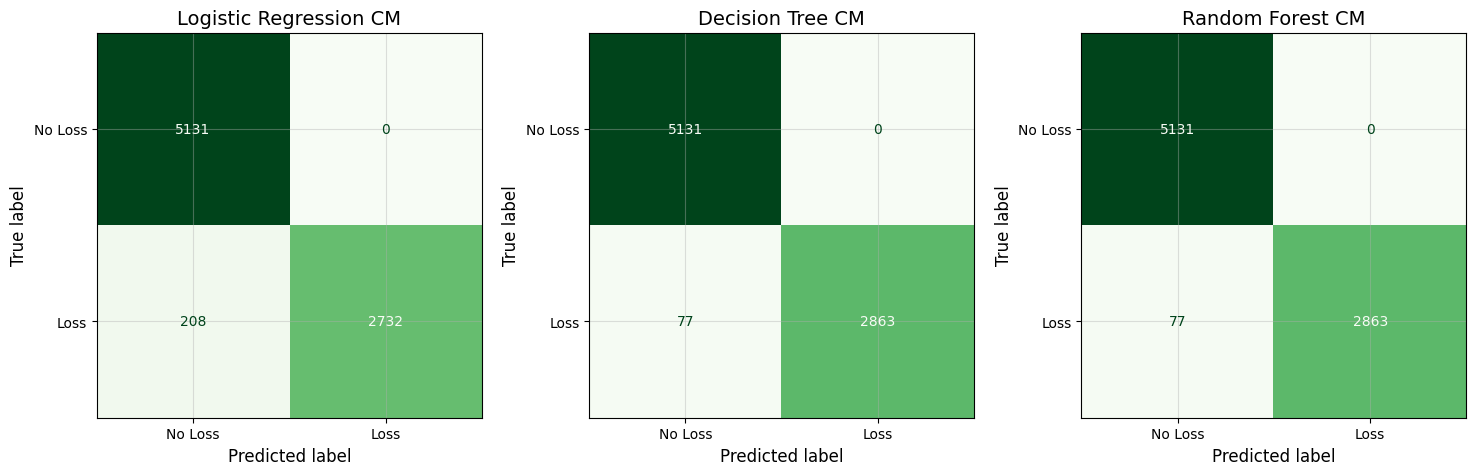

In [64]:
# Confusion Matrices Visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Loss', 'Loss'])
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    axes[i].set_title(f"{r['Model']} CM")
plt.show()

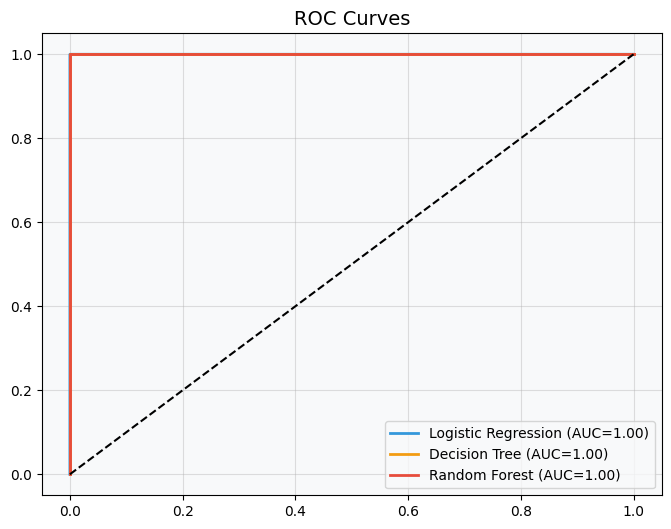

In [54]:
# ROC Curve
plt.figure(figsize=(8, 6))
for r, col in zip(results, [PALETTE[2], PALETTE[3], PALETTE[1]]):
    plt.plot(r['fpr'], r['tpr'], label=f"{r['Model']} (AUC={r['AUC']:.2f})", color=col, lw=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend()
plt.show()

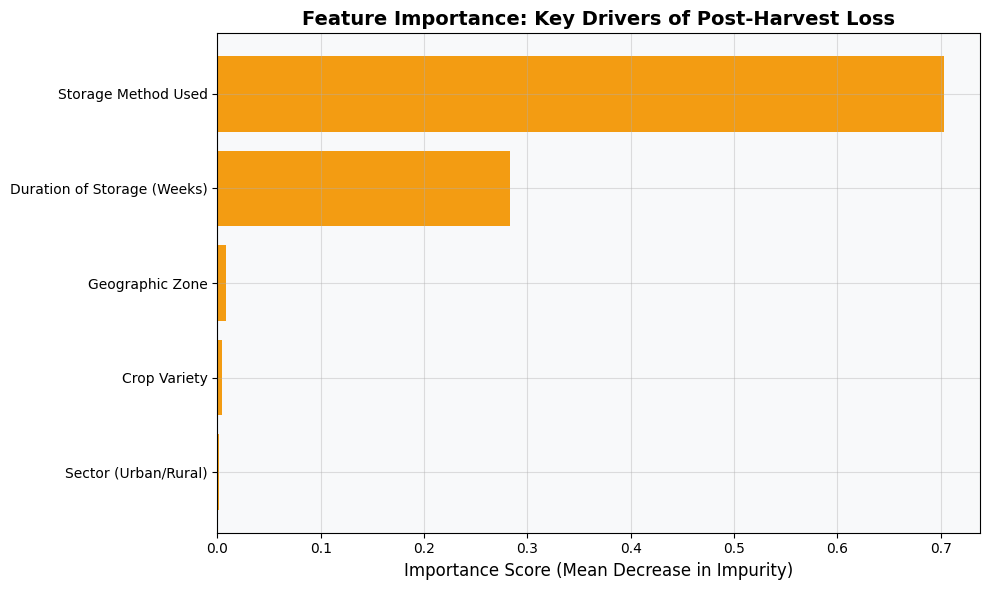

In [66]:
#Feature Importance
rf_importance = pd.DataFrame({
    'Feature': display_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color=PALETTE[3])
plt.title('Feature Importance: Key Drivers of Post-Harvest Loss', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.savefig('fig11_true_importance.png')
plt.show()

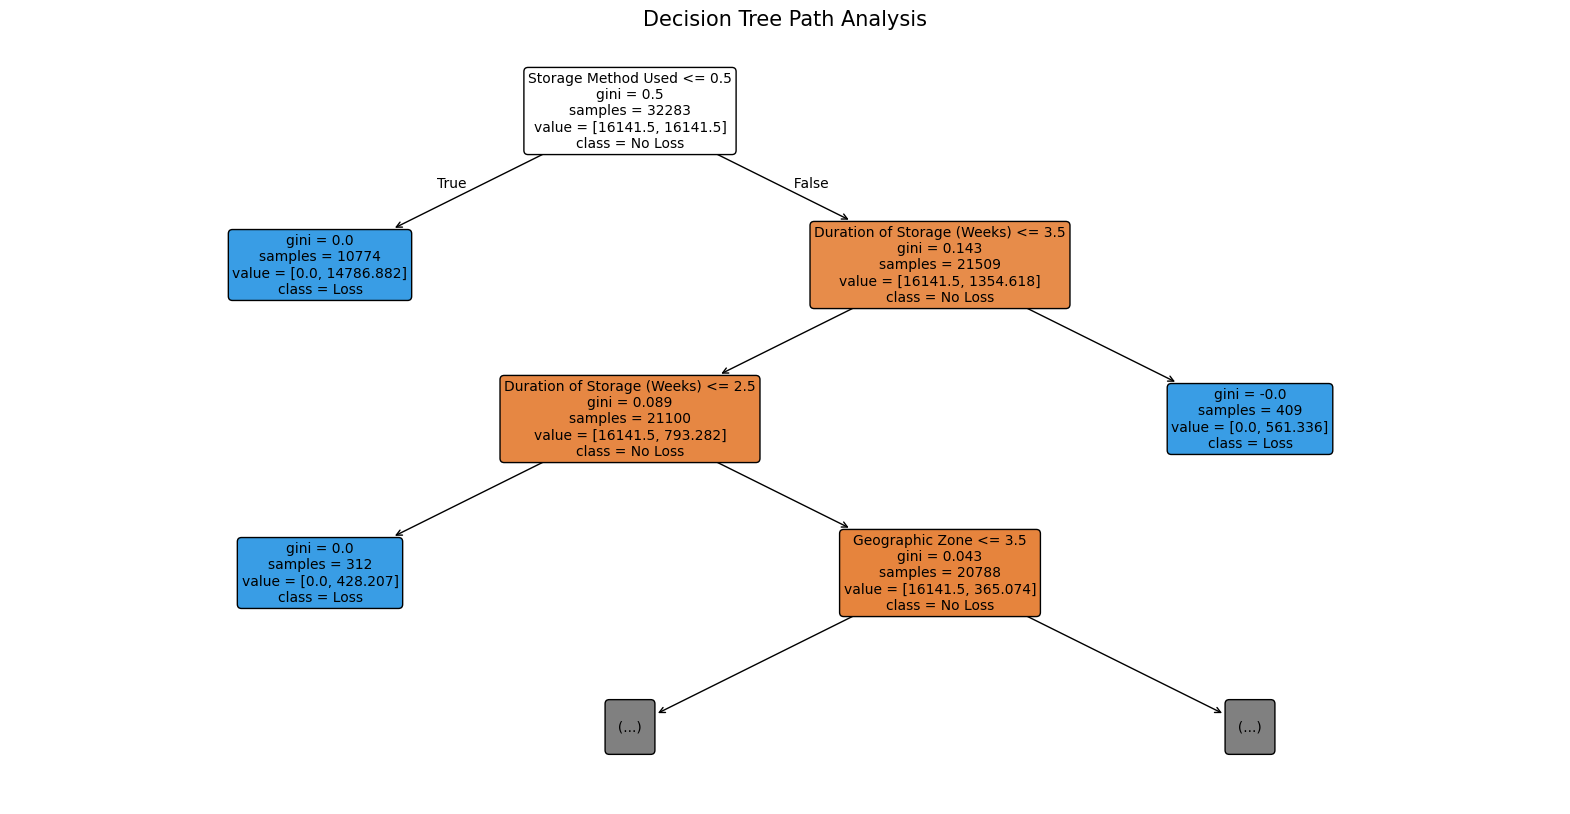

In [67]:
# Decision Tree Visualisation
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, feature_names=display_names,
          class_names=['No Loss', 'Loss'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Path Analysis', fontsize=15)
plt.show()